# 02: Self-Phase Modulation — Spectral Broadening Without Temporal Change

**Summary**: We study self-phase modulation (SPM), the nonlinear counterpart to dispersion.
SPM arises from the intensity-dependent Kerr effect and adds a phase shift proportional to
$|u|^2$. Unlike dispersion, SPM does NOT change the temporal intensity profile — it only
modifies the spectral content of the pulse. We verify this numerically, visualize the spectral
evolution, and connect SPM to real-world applications in supercontinuum generation and
frequency comb technology.

**Key results**:
- Temporal intensity $|u(\xi,\tau)|^2$ is constant near roundoff; the pass threshold is < 10⁻¹⁰
- Spectrum develops characteristic oscillatory structure with spectral broadening
- Visible spectral lobes increase with nonlinear phase; peak counts are threshold-dependent diagnostics
- Spectral broadening scales with input power ($N^2$)

**Physics context**: SPM is the dominant nonlinear effect in optical fibers. It underpins
supercontinuum generation, where narrow laser pulses generate broadband white-light spectra,
and it is central to modern ultrafast photonics.

## Theory: Self-Phase Modulation

### The Nonlinear Phase Shift

When we set $s = 0$ (no dispersion), the NLSE reduces to:

$$i\frac{\partial u}{\partial \xi} + N^2|u|^2 u = 0$$

This has the exact solution:

$$u(\xi, \tau) = u(0, \tau) \cdot \exp\left(i N^2 |u(0,\tau)|^2 \xi\right)$$

Key properties:
- **Temporal intensity**: $|u(\xi,\tau)|^2 = |u(0,\tau)|^2$ — **unchanged** for all $\xi$
- **Phase**: $\phi(\xi,\tau) = N^2 |u(0,\tau)|^2 \xi$ — intensity-dependent (nonlinear!)
- **Maximum phase**: $\phi_{max} = N^2 \cdot |u_{peak}|^2 \cdot \xi_{max}$

### Why the Spectrum Changes

The intensity-dependent phase $\phi(\tau)$ means different parts of the pulse acquire
different phase shifts. The pulse center (high intensity) gets a large phase shift; the
wings (low intensity) get almost none. This **nonlinear chirp** creates new frequency
components, broadening the spectrum.

The instantaneous frequency due to SPM is:

$$\delta\omega(\tau) = -\frac{\partial \phi}{\partial \tau} = -N^2 \xi \frac{\partial |u_0|^2}{\partial \tau}$$

For a Gaussian: the leading edge ($\partial|u|^2/\partial\tau > 0$) is red-shifted, the
trailing edge ($\partial|u|^2/\partial\tau < 0$) is blue-shifted.

### Spectral Peak Diagnostics

The SPM-broadened spectrum develops oscillatory lobes whose visibility increases with
$\phi_{max}$. A simple closed-form peak count is not robust for finite FFT grids because
the result depends on the pulse shape, time window, sampling, and the chosen prominence
threshold. We therefore use `scipy.signal.find_peaks` as a documented diagnostic.

In [12]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import sys
from pathlib import Path
from scipy.signal import find_peaks

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if not (ROOT / "src").exists():
    raise RuntimeError("Run from project root or notebooks/")

sys.path.insert(0, str(ROOT / "src"))

FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

from nlse_ssfm.nlse_utils import (
    create_grid, gaussian_pulse, compute_energy,
    normalized_spectrum, save_figure,
)
from nlse_ssfm.ssfm import ssfm_propagate

## Simulation Setup

We use $s = 0$ (no dispersion) and $N^2 = 1$ to study pure self-phase modulation.

In [13]:
N_t = 2048
tau_window = 20.0
tau, omega, dtau = create_grid(N_t=N_t, tau_window=tau_window)
u0 = gaussian_pulse(tau, chirp=0)

xi_max = 5.0
N_z = 500
s = 0        # NO dispersion
N_sq = 1.0   # Kerr nonlinearity

phi_max = N_sq * np.max(np.abs(u0)**2) * xi_max
print(f"Maximum nonlinear phase: phi_max = {phi_max:.2f} rad")

Maximum nonlinear phase: phi_max = 5.00 rad


## Propagation

In [14]:
xi_arr, u_hist = ssfm_propagate(u0, tau, omega, xi_max=xi_max, N_z=N_z, s=s, N_sq=N_sq)
print(f"Propagation complete: {len(xi_arr)} slices, shape = {u_hist.shape}")

Propagation complete: 501 slices, shape = (501, 2048)


## Result 1: Temporal Intensity Is Constant

SPM does NOT change $|u(\xi,\tau)|^2$. We verify this by computing the maximum intensity
deviation at every propagation step. This should be near roundoff; the pass threshold is 10⁻¹⁰.

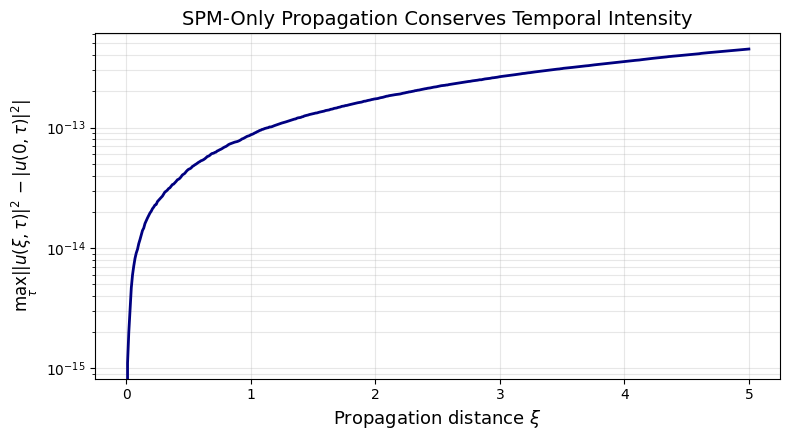

Maximum intensity deviation: 4.49e-13


In [15]:
intensity0 = np.abs(u0)**2
intensity_deviation = np.max(np.abs(np.abs(u_hist)**2 - intensity0[None, :]), axis=1)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(xi_arr, intensity_deviation, color='navy', linewidth=2)
ax.set_xlabel(r'Propagation distance $\xi$', fontsize=13)
ax.set_ylabel(r'$\max_\tau ||u(\xi,\tau)|^2-|u(0,\tau)|^2|$', fontsize=12)
ax.set_title('SPM-Only Propagation Conserves Temporal Intensity', fontsize=14)
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
save_figure(fig, FIG_DIR / "nb02_intensity_constancy.png")
plt.show()

max_intensity_error = np.max(intensity_deviation)
print(f"Maximum intensity deviation: {max_intensity_error:.2e}")
assert max_intensity_error < 1e-10

## Result 2: Spectral Evolution

While the temporal profile is unchanged, the **spectrum** broadens dramatically. We plot
the power spectrum $|\tilde{u}(\omega)|^2$ at several propagation distances.